# Embedding-based Retrieval Model

Модель для рекомендаций на основе сравнения эмбеддинга товара с эмбеддингом текущей корзины.

**Основная идея:**
- Все заказы разбиваются по временным окнам в 2 часа (каждые 2 часа = 1 корзина)
- Модель авторегрессионно предсказывает следующий товар
- Используется Transformer encoder для получения эмбеддинга корзины
- Предсказание через cosine similarity между эмбеддингом корзины и эмбеддингами товаров

## 1. Setup и импорты

In [1]:
import os
import sys
from tqdm import tqdm
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

from tecd_retail_recsys.data import DataPreprocessor
from tecd_retail_recsys.models import EmbeddingRetrievalRecommender
from tecd_retail_recsys.metrics import calculate_metrics
from tecd_retail_recsys.utils import display_metrics_comparison

warnings.simplefilter(action='ignore', category=FutureWarning)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"MPS (Apple Silicon) available: {torch.backends.mps.is_available()}")

PyTorch version: 2.10.0
CUDA available: False
MPS (Apple Silicon) available: True


In [2]:
%load_ext autoreload
%autoreload 2

## 2. Загрузка и предобработка данных

In [3]:
dp = DataPreprocessor(
    day_begin=1082,
    day_end=1308,
    val_days=20,
    test_days=20,
    min_user_interactions=1,
    min_item_interactions=20
)

train_df, val_df, test_df = dp.preprocess()

Starting data preprocessing...
Loading events from t_ecd_small_partial/dataset/small/retail/events
Loaded 236,479,226 total events
Loading items data from t_ecd_small_partial/dataset/small/retail/items.pq
Loaded 250,171 items with features: ['item_id', 'item_brand_id', 'item_category', 'item_subcategory', 'item_price', 'item_embedding']
Merged item features. Data shape: (236479226, 12)
Filtered to 3,758,762 events with action_type='added-to-cart'
After filtering (min_user_interactions=1, min_item_interactions=20): 3,249,972 events, 84,944 users, 30,954 items
Created mappings: 84944 users, 30954 items
Temporal split - Train: days < 1269 (902,543 events), Val: days 1269-1288 (228,339 events), Test: days >= 1289 (223,395 events)
Users in each part (train, val, test) - 7425


In [4]:
print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nNumber of unique items: {train_df['item_id'].nunique()}")
print(f"Number of unique users: {train_df['user_id'].nunique()}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"\nTrain data sample:")
train_df.head()

Train shape: (902543, 12)
Val shape: (228339, 12)
Test shape: (223395, 12)

Number of unique items: 30751
Number of unique users: 7425

Train columns: ['timestamp', 'user_id', 'item_id', 'subdomain', 'action_type', 'os', 'day', 'item_brand_id', 'item_category', 'item_subcategory', 'item_price', 'item_embedding']

Train data sample:


,timestamp,user_id,item_id,subdomain,action_type,os,day,item_brand_id,item_category,item_subcategory,item_price,item_embedding
1252,93485160,79038,20358,main,added-to-cart,android,1082,65693,Foodstuffs and Beverages,Dairy Products and Eggs,-5.766,"[-0.07660043, 0.07826791, 0.016526267, 0.02002..."
1336,93485187,44584,23489,item,added-to-cart,android,1082,60434,Foodstuffs and Beverages,Dairy Products and Eggs,-3.933,"[-0.046968337, 0.023347974, -0.057312813, 0.13..."
1453,93485221,12869,2908,item,added-to-cart,android,1082,240838,Foodstuffs and Beverages,Dairy Products and Eggs,-5.434,"[-0.053301465, 0.022747137, -0.040953826, 0.03..."
2144,93485421,42145,18904,search,added-to-cart,ios,1082,240838,Foodstuffs and Beverages,Seafood and Fish,-3.018,"[-0.09158996, 0.046439428, -0.05373656, 0.0606..."
2189,93485437,15304,14462,catalog,added-to-cart,android,1082,146468,Foodstuffs and Beverages,Culinary Additives and Seasonings,-4.207,"[-0.04469188, -0.036050983, -0.04374125, 0.077..."


Total baskets in train (2-hour windows): 352917

Basket size statistics:
count    352917.000000
mean          2.557380
std           1.931119
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          32.000000
Name: basket_size, dtype: float64

Basket duration statistics (hours):
count    352917.000000
mean         37.650273
std         150.871124
min           0.000000
25%           2.412778
50%           3.384444
75%           8.256389
max        4310.793333
Name: duration_hours, dtype: float64


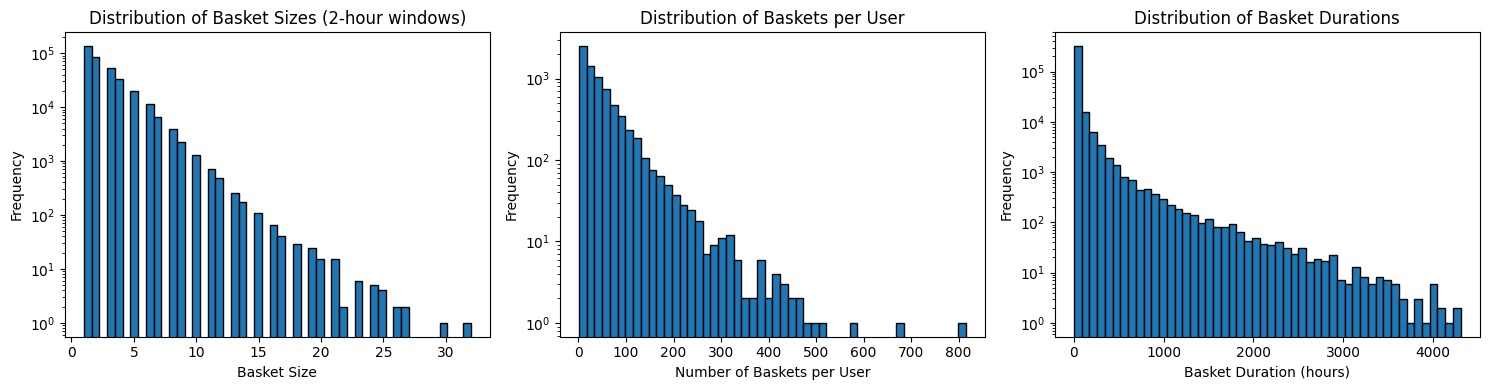

In [5]:
basket_time_window = 7200  # == 2 часа

def create_time_based_baskets(df, time_window=7200):
    """Create baskets based on time windows."""
    df_sorted = df.sort_values(['user_id', 'timestamp'])
    baskets = []
    
    for user_id, user_df in df_sorted.groupby('user_id'):
        user_df = user_df.sort_values('timestamp')
        current_basket = []
        basket_start_time = None
        
        for _, row in user_df.iterrows():
            timestamp = row['timestamp']
            
            if basket_start_time is None:
                basket_start_time = timestamp
                current_basket = [row['item_id']]
            elif timestamp - basket_start_time <= time_window:
                current_basket.append(row['item_id'])
            else:
                if len(current_basket) > 0:
                    baskets.append({
                        'user_id': user_id,
                        'basket_size': len(current_basket),
                        'duration_hours': (timestamp - basket_start_time) / 3600
                    })
                basket_start_time = timestamp
                current_basket = [row['item_id']]
        
        if len(current_basket) > 0:
            last_timestamp = user_df.iloc[-1]['timestamp']
            duration = 0 if basket_start_time is None else (last_timestamp - basket_start_time) / 3600
            baskets.append({
                'user_id': user_id,
                'basket_size': len(current_basket),
                'duration_hours': duration
            })
    
    return pd.DataFrame(baskets)

train_baskets = create_time_based_baskets(train_df, basket_time_window)
print(f"Total baskets in train (2-hour windows): {len(train_baskets)}")
print(f"\nBasket size statistics:")
print(train_baskets['basket_size'].describe())
print(f"\nBasket duration statistics (hours):")
print(train_baskets['duration_hours'].describe())

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(train_baskets['basket_size'], bins=50, edgecolor='black')
plt.xlabel('Basket Size')
plt.ylabel('Frequency')
plt.title('Distribution of Basket Sizes (2-hour windows)')
plt.yscale('log')

plt.subplot(1, 3, 2)
baskets_per_user = train_baskets.groupby('user_id').size()
plt.hist(baskets_per_user, bins=50, edgecolor='black')
plt.xlabel('Number of Baskets per User')
plt.ylabel('Frequency')
plt.title('Distribution of Baskets per User')
plt.yscale('log')

plt.subplot(1, 3, 3)
plt.hist(train_baskets['duration_hours'], bins=50, edgecolor='black')
plt.xlabel('Basket Duration (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Basket Durations')
plt.yscale('log')

plt.tight_layout()
plt.show()

## 3. Инициализация и обучение модели

In [6]:
num_items = train_df['item_id'].max() + 1
print(f"Number of items: {num_items}")

Number of items: 30954


In [10]:
# Инициализация модели
model = EmbeddingRetrievalRecommender(
    num_items=num_items,
    embedding_dim=128,          # Размерность эмбеддингов
    num_heads=4,                # Количество голов в Transformer
    num_layers=2,               # Количество слоев Transformer
    dropout=0.1,                # Dropout для регуляризации
    learning_rate=1e-3,         # Learning rate
    temperature=0.07,           # Температура для InfoNCE loss
    weight_decay=1e-4,          # Weight decay для регуляризации
    max_seq_length=100,         # Максимальная длина последовательности
    max_basket_size=50,         # Максимальный размер корзины
    max_history_baskets=10,     # Максимальное количество исторических корзин
    num_negatives=5,            # Количество негативных примеров
    basket_time_window=7200     # Временное окно для корзины (2 часа)
)

print("Model initialized successfully!")

Model initialized successfully!


In [11]:
model.fit(
    train_df=train_df,
    val_df=val_df,
    batch_size=512,
    num_epochs=10,
    num_workers=4,
    accelerator='auto',
    devices=1
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                     | Params | Mode 
---------------------------------------------------------------------
0 | encoder         | TransformerBasketEncoder | 4.4 M  | train
1 | item_embeddings | Embedding                | 4.0 M  | train
---------------------------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.487    Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## 4. Генерация рекомендаций

In [46]:
print("Generating recommendations for validation set...")

val_recommendations = model.recommend(
    df=train_df,
    k=100,
    batch_size=128,
    exclude_seen=False  # не исключаем уже просмотренные товары
)

print(f"Generated recommendations for {len(val_recommendations)} users")

Generating recommendations for validation set...


Generating recommendations: 100%|██████████| 59/59 [00:01<00:00, 33.31it/s]


Generated recommendations for 7425 users


In [47]:
sample_user_id = list(val_recommendations.keys())[0]
print(f"Sample recommendations for user {sample_user_id}:")
print(f"Top 10 items: {val_recommendations[sample_user_id][:10]}")

sample_user_id = list(val_recommendations.keys())[1]
print(f"Sample recommendations for user {sample_user_id}:")
print(f"Top 10 items: {val_recommendations[sample_user_id][:10]}")

Sample recommendations for user 11:
Top 10 items: [20587, 30249, 10104, 8476, 11413, 8897, 16561, 13903, 14723, 16362]
Sample recommendations for user 14:
Top 10 items: [5631, 17934, 11021, 7982, 16668, 1683, 22887, 18281, 14086, 28042]


## 5. Оценка качества модели

In [48]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2, t3) for t1, t2, t3 in sorted(
        zip(x.item_id, x.timestamp, x.item_price), 
        key=lambda x: x[1]
    )]
).reset_index()
train_grouped.rename({0: 'train_interactions'}, axis=1, inplace=True)

val_grouped = val_df.groupby('user_id').apply(
    lambda x: [(t1, t2, t3) for t1, t2, t3 in sorted(
        zip(x.item_id, x.timestamp, x.item_price), 
        key=lambda x: x[1]
    )]
).reset_index()
val_grouped.rename({0: 'val_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2, t3) for t1, t2, t3 in sorted(
        zip(x.item_id, x.timestamp, x.item_price), 
        key=lambda x: x[1]
    )]
).reset_index()
test_grouped.rename({0: 'test_interactions'}, axis=1, inplace=True)

joined = train_grouped.merge(val_grouped, on='user_id').merge(test_grouped, on='user_id')
print(f"Joined data shape: {joined.shape}")

Joined data shape: (7425, 4)


In [49]:
val_recs_list = []
for user_id in joined['user_id']:
    if user_id in val_recommendations:
        val_recs_list.append(val_recommendations[user_id])
    else:
        val_recs_list.append([])

joined['embedding_retrieval_recs'] = val_recs_list
print(f"Recommendations added to dataframe")

Recommendations added to dataframe


In [51]:
metrics = calculate_metrics(
    joined,
    train_col='train_interactions',
    gt_col='val_interactions',
    model_preds='embedding_retrieval_recs',
    verbose=True
)

[Metrics debug] resolved gt_col='val_interactions' item_id_index=0
[Metrics debug] ratings_true shape: (228339, 3) ratings_pred shape: (742500, 3)
  ratings_true dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  ratings_pred dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  user_id=11 gt_count=22 pred_count=100 overlap=1
  user_id=14 gt_count=5 pred_count=100 overlap=0
    [ID spaces] gt sample=[9341, 16732, 17585, 28024, 30789] range=[9341, 30789] | rec sample=[83, 182, 394, 567, 659] range=[83, 30113]
  user_id=21 gt_count=47 pred_count=100 overlap=7

At k=10:
  MAP@10       = 0.0833
  NDCG@10      = 0.2195
  Precision@10 = 0.1106
  Recall@10    = 0.0340

At k=100:
  MAP@100       = 0.0310
  NDCG@100      = 0.1448
  Precision@100 = 0.0381
  Recall@100    = 0.1160

Other Metrics:
  MRR                 = 0.2253
  Catalog Coverage    = 0.0721
  Diversity     = 0.9549  [0=same recs for all, 1=unique recs]
  Novelty             = 0.7449
  Serendipity         

## 6. Генерация рекомендаций для тестовой выборки

In [52]:
print("Generating recommendations for test set...")

test_recommendations = model.recommend(
    df=pd.concat([train_df, val_df], ignore_index=True),
    k=100,
    batch_size=256,
    exclude_seen=False
)

print(f"Generated recommendations for {len(test_recommendations)} users")

Generating recommendations for test set...


Generating recommendations: 100%|██████████| 30/30 [00:01<00:00, 16.05it/s]


Generated recommendations for 7425 users


In [ ]:
test_recs_list = []
for user_id in joined['user_id']:
    if user_id in test_recommendations:
        test_recs_list.append(test_recommendations[user_id])
    else:
        test_recs_list.append([])

joined['test_recs'] = test_recs_list
joined['train_val_interactions'] = joined['train_interactions'] + joined['val_interactions']

In [54]:
test_metrics = calculate_metrics(
    joined,
    train_col='train_val_interactions',
    gt_col='test_interactions',
    model_preds='test_recs',
    verbose=True
)

[Metrics debug] resolved gt_col='test_interactions' item_id_index=0
[Metrics debug] ratings_true shape: (223395, 3) ratings_pred shape: (742500, 3)
  ratings_true dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  ratings_pred dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  user_id=11 gt_count=9 pred_count=100 overlap=0
    [ID spaces] gt sample=[3094, 13255, 18369, 18732, 19223] range=[3094, 29875] | rec sample=[81, 765, 1327, 1973, 1982] range=[81, 30429]
  user_id=14 gt_count=56 pred_count=100 overlap=4
  user_id=21 gt_count=43 pred_count=100 overlap=8

At k=10:
  MAP@10       = 0.0772
  NDCG@10      = 0.2120
  Precision@10 = 0.1004
  Recall@10    = 0.0313

At k=100:
  MAP@100       = 0.0282
  NDCG@100      = 0.1385
  Precision@100 = 0.0363
  Recall@100    = 0.1151

Other Metrics:
  MRR                 = 0.2105
  Catalog Coverage    = 0.0552
  Diversity     = 0.9414  [0=same recs for all, 1=unique recs]
  Novelty             = 0.7461
  Serendipity     

## 7. Сохранение модели

In [14]:
model_path = 'checkpoints/embedding_retrieval_model.ckpt'
os.makedirs('checkpoints', exist_ok=True)
model.save_model(model_path)
print(f"Model saved to {model_path}")

Model saved to checkpoints/embedding_retrieval_model.ckpt


In [ ]:
# загрузить сохраненную модель

# loaded_model = EmbeddingRetrievalRecommender(
#     num_items=num_items,
#     embedding_dim=128,
#     num_heads=4,
#     num_layers=2,
#     basket_time_window=7200
# )
# loaded_model.load_model('checkpoints/embedding_retrieval_model.ckpt')
# print("Model loaded successfully!")

In [ ]:
# Можно экспериментировать с различными гиперпараметрами (в планах):

# 1. embedding_dim: 64, 128, 256 - размерность эмбеддингов
# 2. num_heads: 2, 4, 8 - количество голов в Transformer
# 3. num_layers: 1, 2, 3, 4 - глубина Transformer
# 4. dropout: 0.0, 0.1, 0.2 - уровень dropout
# 5. learning_rate: 1e-4, 1e-3, 5e-3 - скорость обучения
# 6. temperature: 0.05, 0.07, 0.1 - температура для contrastive loss
# 7. num_negatives: 1, 5, 10, 20 - количество негативных примеров
# 8. max_history_baskets: 5, 10, 20 - количество исторических корзин